In [23]:
# Importing necessary libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
# 1. Load data and clean empty artifact structural lines
df = pd.read_csv(r"D:\Code_Alpha_projects\Unemployment in India.csv", skipinitialspace=True)
df = df.dropna(how='all').reset_index(drop=True)

In [25]:
# Clean structural white space gaps from column headers
df.columns = df.columns.str.strip()

In [26]:

# 2. Type Corrections
# Added .astype(str) to prevent the AttributeError
df['Date'] = pd.to_datetime(df['Date'].astype(str).str.strip(), format='%d-%m-%Y', errors='coerce')
df['Region'] = df['Region'].astype(str).str.strip()
df['Area'] = df['Area'].astype(str).str.strip()
df.head()
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 740 entries, 0 to 739
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    str           
 1   Date                                     740 non-null    datetime64[us]
 2   Frequency                                740 non-null    str           
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    str           
dtypes: datetime64[us](1), float64(3), str(3)
memory usage: 40.6 KB


In [27]:
# 3. Structural Assessment Breakdown
print("--- Dataset Shape Check ---")
print(f"Total Active Rows: {df.shape[0]} | Clean Explored Columns: {df.shape[1]}\n")
print("--- Missing Entries Mapping Summary ---")
print(df.isna().sum())

--- Dataset Shape Check ---
Total Active Rows: 740 | Clean Explored Columns: 7

--- Missing Entries Mapping Summary ---
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64


In [28]:
# 4. Generate Core Statistical Aggregates
print("\n--- Numerical Distributions Overview ---")
print(df.describe().T)


--- Numerical Distributions Overview ---
                                         count                        mean  \
Date                                       740  2019-12-12 18:36:58.378378   
Estimated Unemployment Rate (%)          740.0                   11.787946   
Estimated Employed                       740.0              7204460.025676   
Estimated Labour Participation Rate (%)  740.0                   42.630122   

                                                         min  \
Date                                     2019-05-31 00:00:00   
Estimated Unemployment Rate (%)                          0.0   
Estimated Employed                                   49420.0   
Estimated Labour Participation Rate (%)                13.33   

                                                         25%  \
Date                                     2019-08-31 00:00:00   
Estimated Unemployment Rate (%)                       4.6575   
Estimated Employed                                 119

In [29]:
# 5. Visual Correlation Matrix Heatmap Analysis
plt.figure(figsize=(8, 5))
numeric_cols = ['Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)']

<Figure size 800x500 with 0 Axes>

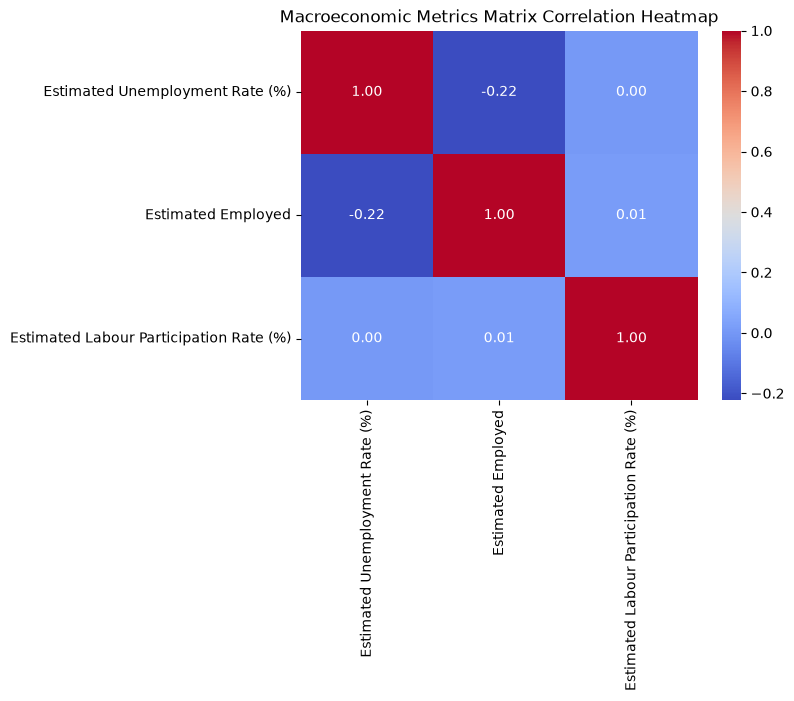

In [30]:
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Macroeconomic Metrics Matrix Correlation Heatmap')
plt.show()